# 01. Getting started

`sentinel_analysis` turns an area of interest and a date range into analysis-ready, co-registered data cubes from many Earth observation sources, and sharpens land surface temperature (LST) from 1 km to about 100 m.

This series of notebooks shows everything the library does, always with real data:

| Notebook | What it covers |
|---|---|
| **01 Getting started** (this one) | credentials, areas of interest, grids, requests, size estimates, product discovery |
| 02 Land surface temperature | Sentinel-3 LST end to end: quality, time series, maps, heat metrics, writing files |
| 03 Multisensor fusion | Sentinel-1/2/3/5P, Landsat, ECOSTRESS, ERA5, CAMS, OpenAQ and terrain in one cube |
| 04 Downscaling | per-scene sharpening to 100 m, model comparison, independent validation, uncertainty, STARFM |
| 05 Animations | animated maps (GIF and MP4) of temperature, vegetation and air quality |
| 06 Worker API | running the same analyses as jobs over HTTP |
| 07 Methane plumes | Sentinel-2 L1C reference and detection scenes around a known methane leak |

Every notebook uses the same place and period (Berlin, August 2026), so downloads made by one are reused by the next.

**Run it** from the repository root:

```bash
uv run --extra notebook --extra cdse --extra optical --extra cloud --extra landsat \
  --extra ecostress --extra auxiliary --extra ml jupyter lab notebooks/
```

This notebook only queries catalogues; it downloads no imagery.

## 1. Setup

Every notebook starts with the same cell: paths, credentials from `.env`, and plotting defaults. Outputs go to `output/notebooks/`, which Git ignores.

In [1]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from dotenv import dotenv_values, load_dotenv

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUT = ROOT / "output" / "notebooks"
WORK = OUT / "work"  # shared download/subset cache: later notebooks reuse it
FIGURES = OUT / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

# Credentials live in the repository's .env (see docs/setup.md). The
# Earthdata token is often kept only in worker/.env; fall back to it.
load_dotenv(ROOT / ".env")
if not os.getenv("EARTHDATA_BEARER_TOKEN"):
    token = dotenv_values(ROOT / "worker" / ".env").get("EARTHDATA_BEARER_TOKEN")
    if token:
        os.environ["EARTHDATA_BEARER_TOKEN"] = token

# Upstream notices (numpy/xarray/matplotlib internals, all-NaN slices of
# cloudy scenes) that say nothing about the analysis.
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": False, "image.origin": "upper"})
pd.set_option("display.max_colwidth", 70)

In [2]:
import sentinel_analysis as sa

print("sentinel_analysis", sa.__version__)
sa.build_info()  # version and git commit, recorded in every result's provenance

sentinel_analysis 0.2.0


{'version': '0.2.0',
 'git_commit': 'c629cfd17920f30d0e115813cdf9be6929b12759',
 'git_dirty': True}

## 2. Check credentials

Each data provider needs its own account. `check_credentials()` authenticates against every one that is configured and reports expiry dates when the token carries one, without ever printing a secret. The same check is available as `sentinel-analysis check-credentials` and as `GET /health/ready` in the worker.

In [3]:
checks = sa.check_credentials(ROOT / ".env")
pd.DataFrame({name: check.to_dict() for name, check in checks.items()}).T

,status,detail,expires_at
cdse_oauth_client,ok,authenticated,None
cdse_account,ok,authenticated,None
earthdata,ok,authenticated; expires in 27 days,2026-11-05T08:56:21+00:00
cds,ok,authenticated,None
ads,ok,authenticated,None
openaq,ok,authenticated,None


| Provider | Used for |
|---|---|
| `cdse_oauth_client`, `cdse_account` | Copernicus Data Space: Sentinel-1/2/3/5P catalogues and downloads, openEO |
| `earthdata` | NASA: ECOSTRESS, and ASF HyP3 for Sentinel-1 |
| `cds` | Copernicus Climate Data Store: ERA5 |
| `ads` | Copernicus Atmosphere Data Store: CAMS |
| `openaq` | OpenAQ ground stations |

Landsat, Sentinel-2 COGs and Sentinel-1 RTC from Microsoft Planetary Computer need no account.

## 3. Areas of interest

An `AOI` is a WGS84 bounding box. A few cities are registered with sensible defaults (`CitySpec`), and any box works.

In [4]:
cities = pd.DataFrame([
    {"id": c.city_id, "name": c.name, "country": c.country, "west": c.aoi.west, "south": c.aoi.south,
     "east": c.aoi.east, "north": c.aoi.north, "target_resolution_m": c.target_resolution_m}
    for c in sa.list_cities()
])
cities

,id,name,country,west,south,east,north,target_resolution_m
0,berlin,Berlin,Germany,13.20,52.40,13.55,52.58,100
1,guadalajara,Guadalajara,Mexico,-103.60,20.50,-103.20,20.85,100
2,lagos,Lagos,Nigeria,2.70,6.35,3.70,6.80,100
3,mexico-city,Mexico City,Mexico,-99.35,19.15,-98.95,19.60,100
4,nairobi,Nairobi,Kenya,36.55,-1.45,37.15,-1.05,100


In [5]:
berlin = sa.get_city("berlin")
madrid = sa.AOI(west=-3.80, south=40.35, east=-3.60, north=40.50)  # any bounding box
berlin.aoi, madrid.as_wkt()

(AOI(west=13.2, south=52.4, east=13.55, north=52.58),
 'POLYGON ((-3.8 40.35, -3.6 40.35, -3.6 40.5, -3.8 40.5, -3.8 40.35))')

## 4. Analysis grids

All data is placed on projected grids in the UTM zone of the AOI centre. A typical setup uses two grids that share one CRS:

* a **thermal grid** at 1 km, the native scale of Sentinel-3 LST;
* a **predictor grid** at 100 m for Sentinel-2, Sentinel-1, Landsat, ECOSTRESS and terrain.

`AnalysisGrid.for_city` and `AnalysisGrid.for_aoi` build them; `chips()` tiles a grid into equal sub-grids (for example 2.5 km patches for machine learning).

In [6]:
predictor_grid = sa.AnalysisGrid.for_city(berlin, resolution_m=100)
thermal_grid = sa.AnalysisGrid.for_city(berlin, resolution_m=1000)
madrid_grid = sa.AnalysisGrid.for_aoi(madrid, resolution_m=100)

pd.DataFrame([
    {"grid": name, "crs": g.crs, "resolution_m": g.resolution_m, "width": g.width, "height": g.height, "cells": g.width * g.height}
    for name, g in [("Berlin predictor", predictor_grid), ("Berlin thermal", thermal_grid), ("Madrid predictor", madrid_grid)]
])

,grid,crs,resolution_m,width,height,cells
0,Berlin predictor,EPSG:32633,100.0,243,206,50058
1,Berlin thermal,EPSG:32633,1000.0,25,22,550
2,Madrid predictor,EPSG:32630,100.0,172,169,29068


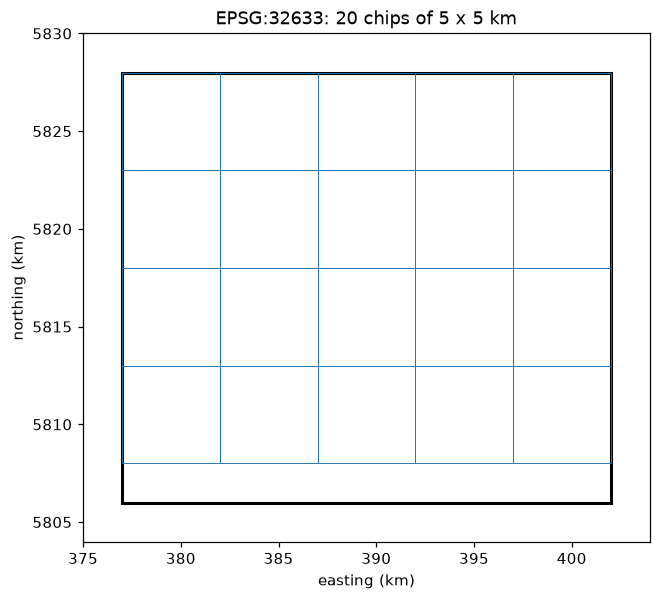

In [7]:
chips = thermal_grid.chips(5000)  # 5 x 5 km tiles
fig, ax = plt.subplots(figsize=(7, 6))
west, south, east, north = (v / 1e3 for v in thermal_grid.bounds)
ax.add_patch(plt.Rectangle((west, south), east - west, north - south, fill=False, lw=2, color="black", label="Berlin grid"))
for chip in chips:
    w, s, e, n = (v / 1e3 for v in chip.bounds)
    ax.add_patch(plt.Rectangle((w, s), e - w, n - s, fill=False, lw=0.6, color="tab:blue"))
ax.set_xlim(west - 2, east + 2)
ax.set_ylim(south - 2, north + 2)
ax.set_aspect("equal")
ax.set_xlabel("easting (km)")
ax.set_ylabel("northing (km)")
ax.set_title(f"{thermal_grid.crs}: {len(chips)} chips of 5 x 5 km")
fig.savefig(FIGURES / "01_grid_chips.png", bbox_inches="tight")
plt.show()

## 5. A declarative request

`AnalysisRequest` describes a whole analysis: where, when, which sensors and auxiliary sources, which grids and every processing policy. It is plain data, so it can be saved as JSON, versioned, sent to the worker, or run from the command line.

In [8]:
import dataclasses

request = sa.AnalysisRequest.for_city(
    berlin, "2026-08-01", "2026-08-21",
    sensors=("sentinel3", "sentinel2"),
    resolution_m=100,
    max_products_per_sensor=12,
)
request = dataclasses.replace(
    request,
    sentinel2_source="stac_cog",  # read Sentinel-2 in place instead of 1 GB archives
    s2_cloud_cover_max=60,
    thermal_overpass="day",       # daytime Sentinel-3 passes only
    terrain_predictors=True,      # elevation, slope, solar illumination
    downscale=sa.DownscaleSpec(model="random_forest"),
)
path = request.save_json(OUT / "berlin_request.json")
print(path.read_text()[:900], "...")
assert sa.AnalysisRequest.from_json(path) == request

{
  "aoi": {
    "east": 13.55,
    "north": 52.58,
    "south": 52.4,
    "west": 13.2
  },
  "auxiliary": [],
  "downscale": {
    "coarse_consistent": true,
    "correction": "smooth",
    "mask_unobserved": true,
    "min_samples": 30,
    "model": "random_forest",
    "model_options": {},
    "predictor_sensor": "sentinel2",
    "predictors": [],
    "target": "lst"
  },
  "end": "2026-08-21",
  "grid": {
    "bounds": [
      377500.0,
      5806500.0,
      401800.0,
      5827100.0
    ],
    "city_id": "berlin",
    "crs": "EPSG:32633",
    "grid_id": "berlin:EPSG:32633:100m",
    "resolution_m": 100.0
  },
  "max_products_per_sensor": 12,
  "on_product_error": "skip",
  "predictor_grid": {
    "bounds": [
      377500.0,
      5806500.0,
      401800.0,
      5827100.0
    ],
    "city_id": "berlin",
    "crs": "EPSG:32633",
    "grid_id": "berlin:EPSG:32633:100m",
    "resolut ...


Invalid requests fail immediately, with a message that says why:

In [9]:
for bad in (
    {"thermal_overpass": "dusk"},
    {"sensors": ("sentinel3",), "downscale": sa.DownscaleSpec()},  # downscaling needs Sentinel-2
    {"start": "2026-08-21", "end": "2026-08-01"},
):
    try:
        dataclasses.replace(request, **bad)
    except ValueError as error:
        print(f"{list(bad)}: {error}")

['thermal_overpass']: thermal_overpass must be one of ('any', 'day', 'night')
['sensors', 'downscale']: downscale needs its predictor sensor 'sentinel2' in sensors
['start', 'end']: Analysis start must not be after end


## 6. Plan and size before running

`plan` lists the steps without touching the network. `estimate_request` gives the order of magnitude of the in-memory cubes, and `execute()` refuses requests above `RequestLimits` before downloading anything (16 GB by default; the worker uses 8 GB).

In [10]:
workflow = sa.AnalysisWorkflow(request)
for step in workflow.plan.steps:
    print(f"{step.sensor:12s} {step.action}")
sa.estimate_request(request).to_dict()

sentinel3    discover -> acquire -> preprocess -> harmonize
sentinel2    discover -> acquire -> preprocess -> harmonize


{'aoi_km2': 474.3,
 'cells': {'sentinel3': 550, 'sentinel2': 50058},
 'estimated_gb': 0.093}

In [11]:
# The same AOI at 10 m with 100 products per sensor is far too large for one machine:
huge = dataclasses.replace(
    request,
    predictor_grid=sa.AnalysisGrid.for_city(berlin, resolution_m=10),
    grid=sa.AnalysisGrid.for_city(berlin, resolution_m=10),
    max_products_per_sensor=100,
)
try:
    sa.check_request(huge, sa.RequestLimits(max_estimated_gb=16))
except sa.RequestTooLargeError as error:
    print(error)

Request too large: estimated cube size is 75.9 GB (limit 16.0 GB); reduce the AOI, the period or max_products_per_sensor, or coarsen the predictor grid


## 7. Discover products

`discover()` searches every requested sensor's catalogue and ranks the results (online first, least cloud), without downloading. Here we ask all six imaging sensors what exists over Berlin in these three weeks.

In [12]:
all_sensors = dataclasses.replace(
    request,
    sensors=("sentinel3", "sentinel2", "sentinel1", "sentinel5p", "landsat", "ecostress"),
    sentinel1_backend="pc_rtc",
    downscale=None,
    max_products_per_sensor=40,
)
discovered = sa.AnalysisWorkflow(all_sensors).discover()

rows = []
for sensor, products in discovered.items():
    for product in products:
        rows.append({"sensor": sensor, "time": pd.Timestamp(product.start_datetime), "cloud_cover": product.cloud_cover, "name": product.name})
products = pd.DataFrame(rows)
products.groupby("sensor").agg(products=("name", "size"), first=("time", "min"), last=("time", "max"), median_cloud=("cloud_cover", "median"))

,products,first,last,median_cloud
sensor,,,,
ecostress,18,2026-08-11 08:33:55.474000+00:00,2026-08-18 07:50:11.364000+00:00,NaN
landsat,6,2026-08-06 10:02:21.788666+00:00,2026-08-15 09:56:35.296465+00:00,35.350000
sentinel1,16,2026-08-01 17:00:04.889213+00:00,2026-08-20 16:51:55.636621+00:00,NaN
sentinel2,19,2026-08-03 10:15:59.024000+00:00,2026-08-20 10:17:01.024000+00:00,25.081235
sentinel3,40,2026-08-01 09:01:46.976770+00:00,2026-08-21 09:21:44.351524+00:00,36.755083
sentinel5p,37,2026-08-01 10:30:34+00:00,2026-08-21 12:36:11+00:00,NaN


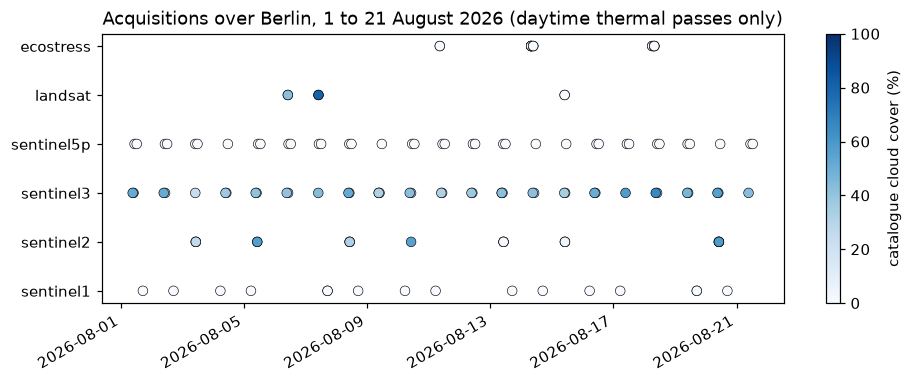

,sensor,time,cloud_cover,name
0,sentinel3,2026-08-09 08:57:17.033925+00:00,12.334667,S3B_SL_2_LST____20260809T085717_20260809T090017_20260810T175512_01...
1,sentinel3,2026-08-13 08:53:32.713635+00:00,15.003944,S3B_SL_2_LST____20260813T085333_20260813T085633_20260814T191331_01...
2,sentinel3,2026-08-12 09:55:24.487459+00:00,21.642833,S3A_SL_2_LST____20260812T095524_20260812T095824_20260814T000037_01...
3,sentinel3,2026-08-11 10:21:35.383345+00:00,21.804056,S3A_SL_2_LST____20260811T102135_20260811T102435_20260813T001727_01...
4,sentinel3,2026-08-14 10:05:21.004536+00:00,23.117500,S3B_SL_2_LST____20260814T100521_20260814T100821_20260815T174611_01...
5,sentinel3,2026-08-03 09:50:23.896256+00:00,24.164444,S3B_SL_2_LST____20260803T095024_20260803T095324_20260804T212346_01...
6,sentinel3,2026-08-10 10:09:05.372192+00:00,28.556278,S3B_SL_2_LST____20260810T100905_20260810T101205_20260811T174044_01...
7,sentinel3,2026-08-08 09:59:08.810295+00:00,28.594667,S3A_SL_2_LST____20260808T095909_20260808T100209_20260810T002757_01...


In [13]:
fig, ax = plt.subplots(figsize=(10, 3.6))
order = ["sentinel1", "sentinel2", "sentinel3", "sentinel5p", "landsat", "ecostress"]
for row, sensor in enumerate(order):
    subset = products[products.sensor == sensor]
    cloud = subset.cloud_cover.fillna(0).clip(0, 100)
    points = ax.scatter(subset.time, [row] * len(subset), c=cloud, cmap="Blues", vmin=0, vmax=100, s=40, edgecolor="black", lw=0.4)
ax.set_yticks(range(len(order)), order)
ax.set_title("Acquisitions over Berlin, 1 to 21 August 2026 (daytime thermal passes only)")
plt.colorbar(points, ax=ax, label="catalogue cloud cover (%)")
fig.autofmt_xdate()
fig.savefig(FIGURES / "01_acquisitions.png", bbox_inches="tight")
plt.show()
products.head(8)

## 8. Day and night thermal passes

Sentinel-3 passes over Berlin around 10:00 and 21:00 local solar time. The temperature of a sunlit surface and its relation to vegetation are different by night, so downscaling should use daytime passes only. `thermal_overpass="day"` filters them during discovery, before ranking, so night passes are never downloaded.

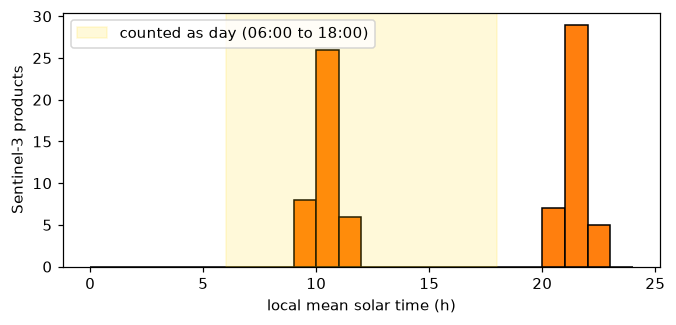

81 products: 40 day passes, 41 night passes


In [14]:
any_pass = dataclasses.replace(all_sensors, sensors=("sentinel3",), thermal_overpass="any", max_products_per_sensor=200)
candidates = sa.AnalysisWorkflow(any_pass).discover()["sentinel3"]
longitude = (berlin.aoi.west + berlin.aoi.east) / 2
hours = [sa.local_solar_hour(p.start_datetime, longitude) for p in candidates]

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(hours, bins=np.arange(0, 25, 1), color="tab:orange", edgecolor="black")
ax.axvspan(6, 18, color="gold", alpha=0.15, label="counted as day (06:00 to 18:00)")
ax.set_xlabel("local mean solar time (h)")
ax.set_ylabel("Sentinel-3 products")
ax.legend()
plt.show()

day = sa.filter_overpass(candidates, longitude=longitude, overpass="day")
night = sa.filter_overpass(candidates, longitude=longitude, overpass="night")
print(f"{len(candidates)} products: {len(day)} day passes, {len(night)} night passes")

## 9. The same from the command line

Everything above is also available from the `sentinel-analysis` command, driven by the JSON request saved in section 5:

```bash
sentinel-analysis check-credentials           # section 2
sentinel-analysis plan request.json           # section 6 (steps and size estimate)
sentinel-analysis discover request.json       # section 7
sentinel-analysis run request.json output/run # download, process, fuse, downscale, save
```

In [15]:
import subprocess

result = subprocess.run(["sentinel-analysis", "plan", str(OUT / "berlin_request.json")], capture_output=True, text=True, check=True)
print(result.stdout)

{
  "steps": [
    {
      "sensor": "sentinel3",
      "action": "discover -> acquire -> preprocess -> harmonize",
      "variables": []
    },
    {
      "sensor": "sentinel2",
      "action": "discover -> acquire -> preprocess -> harmonize",
      "variables": []
    }
  ],
  "estimate": {
    "aoi_km2": 474.3,
    "cells": {
      "sentinel3": 550,
      "sentinel2": 50058
    },
    "estimated_gb": 0.093
  }
}



## Next

[02 Land surface temperature](02_land_surface_temperature.ipynb) downloads and processes the Sentinel-3 scenes discovered here.